In [90]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')





# **Data loading and Exploration**

In [92]:
df = pd.read_csv('diabetes.csv')


print("\nDataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nTarget Distribution:")
print(df['Outcome'].value_counts())
print("\nDataset Info:")
print(f"Total samples: {len(df)}")
print(f"Classes: {df['Outcome'].unique()}")


Dataset Shape: (768, 9)

First few rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Target Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Dataset Info:
Total samples: 768
Classes: [1 0]


# **EDA**


Basic Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.00000

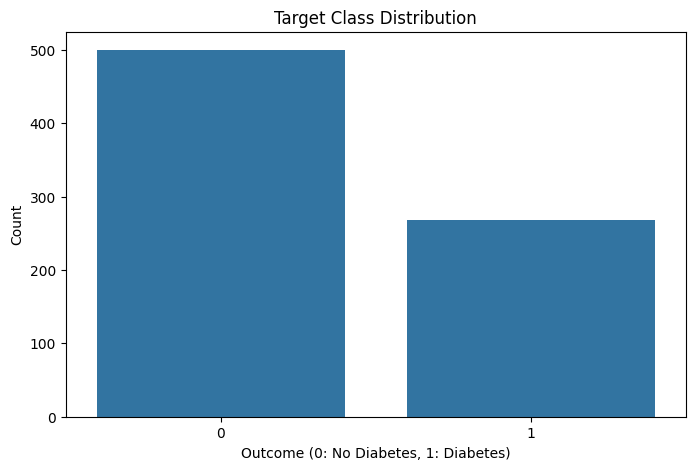

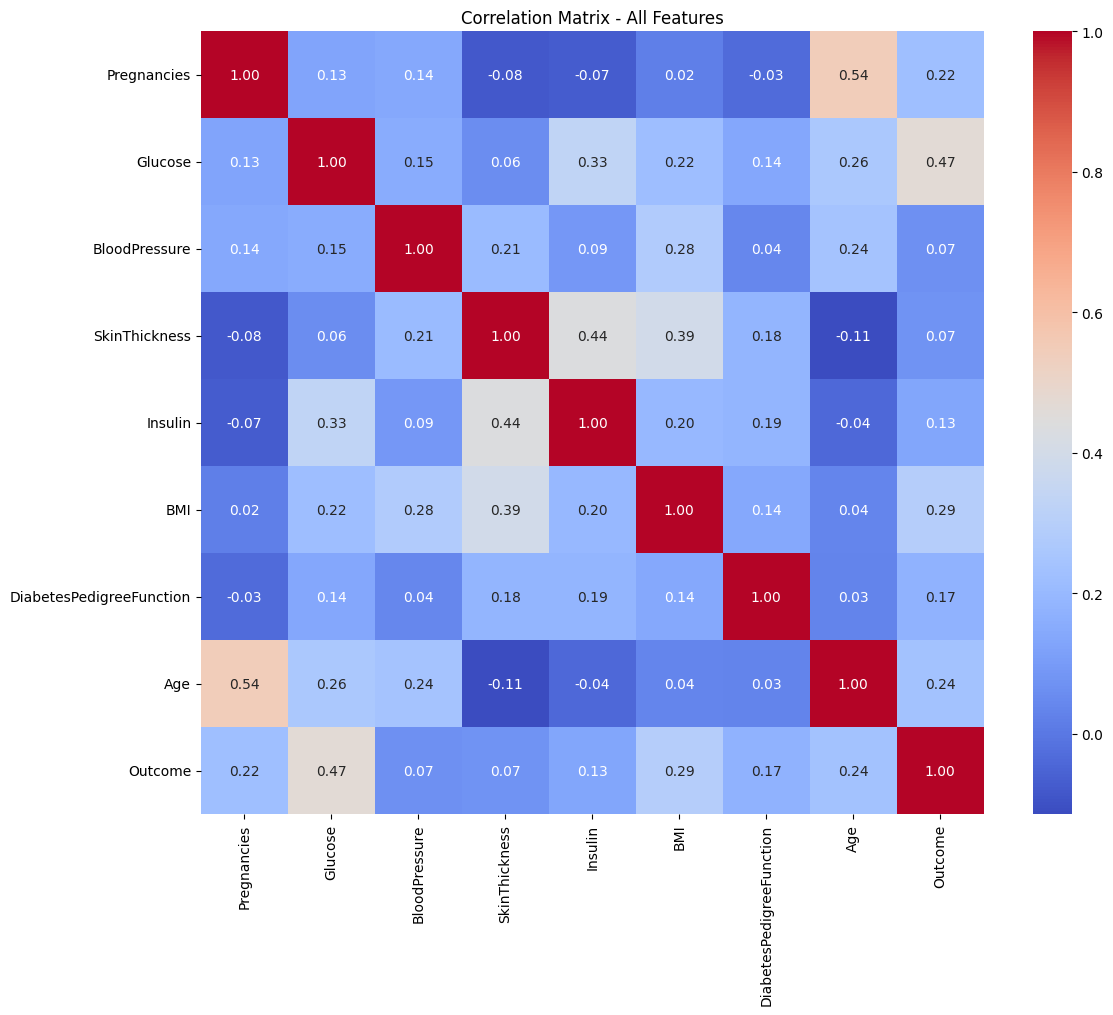

Replaced Glucose zeros with median: 117.00
Replaced BloodPressure zeros with median: 72.00
Replaced SkinThickness zeros with median: 29.00
Replaced Insulin zeros with median: 125.00
Replaced BMI zeros with median: 32.30


In [93]:


print("\nBasic Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())
print(f"Total missing values: {df.isnull().sum().sum()}")

''' Check for zero values '''
print("\nZero values check (potentially missing data):")
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zeros ({zero_count/len(df)*100:.2f}%)")


plt.figure(figsize=(8, 5))
sns.countplot(x='Outcome', data=df)
plt.title('Target Class Distribution')
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)')
plt.ylabel('Count')
plt.show()


plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix - All Features')
plt.tight_layout()
plt.show()

''' Handling zero values and Replace zeroes with median in specific columns '''
df_clean = df.copy()

for col in zero_cols:
    if (df_clean[col] == 0).sum() > 0:
        median_val = df_clean[df_clean[col] != 0][col].median()
        df_clean[col] = df_clean[col].replace(0, median_val)
        print(f"Replaced {col} zeros with median: {median_val:.2f}")


df = df_clean

# **Train and Split**

In [95]:

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



# **Feature Scaling**

In [97]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)




# **Model Training**

In [99]:

knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

knn.fit(X_train_scaled, y_train)

print("\nKNN Model trained successfully!")
print(f"Number of neighbors (k): {knn.n_neighbors}")
print(f"Distance metric: {knn.metric}")



KNN Model trained successfully!
Number of neighbors (k): 5
Distance metric: euclidean


# **Prediction**

In [112]:

y_pred = knn.predict(X_test_scaled)
y_pred_proba = knn.predict_proba(X_test_scaled)



# **Model Evaluation**


Training Accuracy: 0.8306 (83.06%)
Testing Accuracy: 0.7532 (75.32%)

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.80      0.83      0.81       100
    Diabetes       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154


Confusion Matrix:
[[83 17]
 [21 33]]

True Negatives: 83
False Positives: 17
False Negatives: 21
True Positives: 33


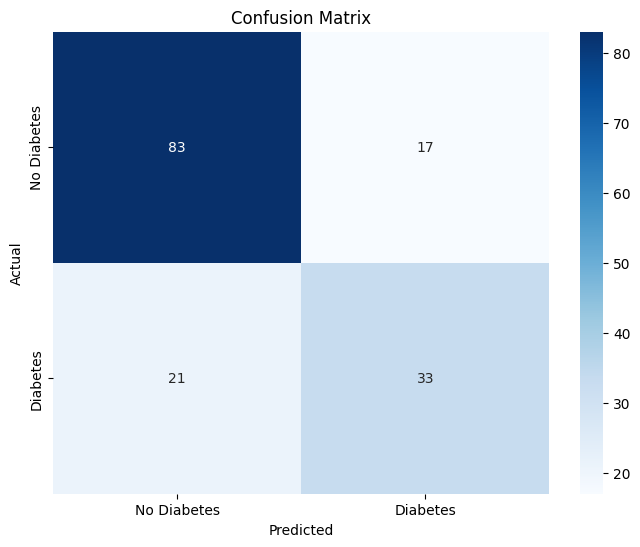


ROC-AUC Score: 0.7886


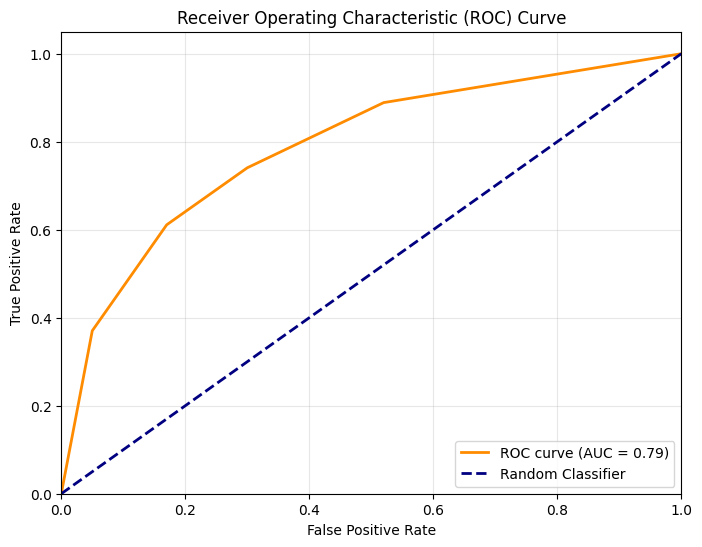

In [102]:


train_accuracy = knn.score(X_train_scaled, y_train)
test_accuracy = knn.score(X_test_scaled, y_test)

print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Testing Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))


cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"\nROC-AUC Score: {roc_auc:.4f}")


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
